# Embedding Benchmark: BiomedBERT vs Bioformer-16L

Benchmarks two biomedical BERT models for **retrieval quality** using the PubMed bulk corpus from `02_pubmed_ingestion.ipynb`.

## Models compared

| Model | Params | Pre-trained on |
|---|---|---|
| `microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract` | ~110M | PubMed abstracts (MLM) |
| `bioformers/bioformer-16L` | ~85M | PubMed + PMC full text (MLM) |

## Why this benchmark matters

The final system uses a BioBERT-family model to retrieve PubMed abstracts for a clinical query. Choosing the right embedding model directly affects retrieval precision. This notebook compares two candidates under identical conditions.

## Section 1 — Configuration and Corpus Loading

In [14]:
import json

PAPERS_FOLDER = "../data/raw/pubmed_bulk_corpus.json"

# Set to None to use all papers per category.
# Set to an integer (e.g. 50) to cap for fast iteration on large corpora.
MAX_PAPERS_PER_CATEGORY = 300

In [15]:
from collections import Counter

with open(PAPERS_FOLDER, "r") as f:
    raw_papers = json.load(f)

cats = Counter(p["mesh_category"] for p in raw_papers)
print(f"Papers loaded: {len(raw_papers)}, MeSH categories: {len(cats)}")
for cat, n in sorted(cats.items()):
    print(f"  {cat}: {n} papers")

Papers loaded: 29108, MeSH categories: 24
  Bacterial Infections and Mycoses: 1924 papers
  Cardiovascular Diseases: 919 papers
  Congenital, Hereditary, and Neonatal Diseases and Abnormalities: 941 papers
  Diagnostic Techniques and Procedures: 316 papers
  Digestive System Diseases: 1206 papers
  Endocrine System Diseases: 589 papers
  Eye Diseases: 1681 papers
  Hemic and Lymphatic Diseases: 1396 papers
  Immune System Diseases: 517 papers
  Mental Disorders: 1439 papers
  Musculoskeletal Diseases: 1837 papers
  Neoplasms: 1677 papers
  Nervous System Diseases: 1362 papers
  Nutritional and Metabolic Diseases: 1258 papers
  Otorhinolaryngologic Diseases: 1584 papers
  Parasitic Diseases: 1963 papers
  Respiratory Tract Diseases: 1001 papers
  Skin and Connective Tissue Diseases: 830 papers
  Stomatognathic Diseases: 1648 papers
  Surgical Procedures, Operative: 521 papers
  Therapeutics: 333 papers
  Urogenital Diseases: 1006 papers
  Virus Diseases: 1809 papers
  Wounds and Injurie

## Section 2 — Flatten into DataFrame

The corpus is a flat list of papers, each tagged with a `mesh_category`. We group by category, optionally cap per category for fast iteration, then build a flat DataFrame. Papers with missing or very short abstracts (< 50 characters) are dropped.

In [29]:
import re
import random
import pandas as pd
from collections import defaultdict

random.seed(42)

def slugify(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", text.lower()).strip("_")

by_cat = defaultdict(list)
for p in raw_papers:
    by_cat[p.get("mesh_category", "")].append(p)

rows = []
for cat, papers in by_cat.items():
    subset = random.sample(papers, min(MAX_PAPERS_PER_CATEGORY, len(papers))) if MAX_PAPERS_PER_CATEGORY else papers
    for i, p in enumerate(subset):
        abstract = (p.get("abstract") or "").strip()
        if len(abstract) < 50:
            continue
        pmid = p.get("pmid", "")
        rows.append({
            "doc_id": pmid if pmid else f"{slugify(cat)}_{i}",
            "mesh_category": cat,
            "title": p.get("title", ""),
            "abstract": abstract,
            "pmid": pmid,
            "year": p.get("year", ""),
        })

df = pd.DataFrame(rows).reset_index(drop=True)
print(f"Total raw papers:              {len(raw_papers)}")
print(f"After filtering short/missing: {len(df)}")
df.head(3)

Total raw papers:              29108
After filtering short/missing: 7196


,doc_id,mesh_category,title,abstract,pmid,year
0,40640262,Bacterial Infections and Mycoses,The presence and relative abundance of salivar...,Colorectal cancer (CRC) is the third most comm...,40640262,2025
1,34887176,Bacterial Infections and Mycoses,AAUS guideline for chlamydial urethritis.,Urogenital chlamydial infection is the most co...,34887176,2022
2,39578415,Bacterial Infections and Mycoses,Australasian hidradenitis suppurativa manageme...,Hidradenitis Suppurativa is a burdensome infla...,39578415,2025


## Section 3 — Corpus Statistics

Before embedding, understand the data distribution. Highly imbalanced specialties will dominate the aggregate benchmark metrics, the per-specialty breakdown (Section 7) is more informative than the overall average.

mesh_category
Bacterial Infections and Mycoses                                   300
Virus Diseases                                                     300
Surgical Procedures, Operative                                     300
Mental Disorders                                                   300
Wounds and Injuries                                                300
Immune System Diseases                                             300
Endocrine System Diseases                                          300
Nutritional and Metabolic Diseases                                 300
Skin and Connective Tissue Diseases                                300
Congenital, Hereditary, and Neonatal Diseases and Abnormalities    300
Hemic and Lymphatic Diseases                                       300
Cardiovascular Diseases                                            300
Urogenital Diseases                                                300
Eye Diseases                                                   

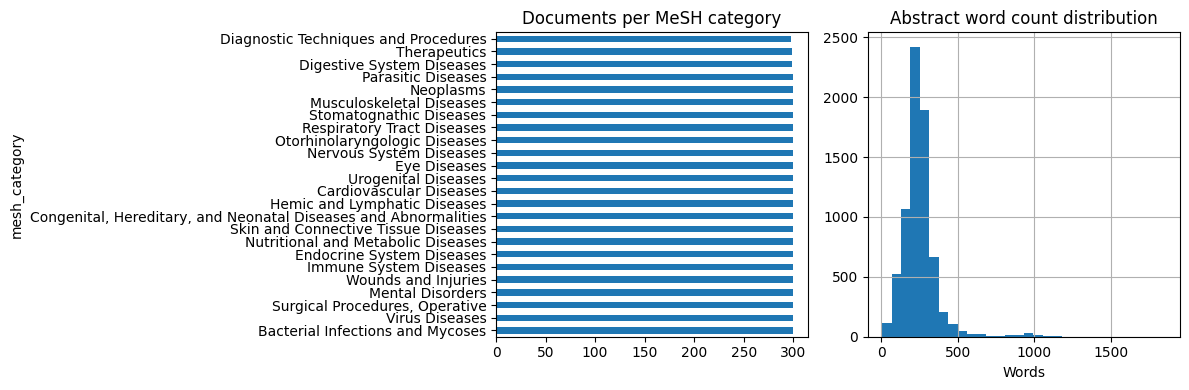

In [30]:
import matplotlib.pyplot as plt

counts = df["mesh_category"].value_counts()
print(counts.to_string())

df["abstract_len"] = df["abstract"].str.split().str.len()
print(f"\nAbstract word count — mean: {df['abstract_len'].mean():.0f}, median: {df['abstract_len'].median():.0f}")
print(f"Max: {df['abstract_len'].max()}, Min: {df['abstract_len'].min()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot(kind="barh", ax=axes[0], title="Documents per MeSH category")
df["abstract_len"].hist(bins=30, ax=axes[1])
axes[1].set_title("Abstract word count distribution")
axes[1].set_xlabel("Words")
plt.tight_layout()
plt.show()

## Section 4 — Embedding Function (SentenceTransformer with Explicit Pooling)

| Parameter | Value | Why |
|---|---|---|
| `pooling_mode_mean_tokens=True` | Mean over non-padding tokens | Standard for BERT-family MLM models |
| `normalize_embeddings=True` | L2 normalization | Dot product == cosine similarity; consistent with Qdrant |
| `max_seq_length=512` | 512 tokens | Both models' max positional embedding length |

In [31]:
import time
import numpy as np
import transformers
from sentence_transformers import SentenceTransformer, models

# Suppress HuggingFace verbosity so MLM-head key mismatches don't pollute output.
# These warnings are expected: the checkpoint includes MLM classification weights
# that are not part of the base encoder we use here.
transformers.logging.set_verbosity_error()


def make_st_model(model_name: str, max_length: int = 512) -> SentenceTransformer:
    """Build SentenceTransformer with explicit mean pooling over non-padding tokens."""
    word_model = models.Transformer(model_name, max_seq_length=max_length)
    pooling_model = models.Pooling(
        word_model.get_word_embedding_dimension(),
        pooling_mode_mean_tokens=True,
        pooling_mode_cls_token=False,
        pooling_mode_max_tokens=False,
    )
    return SentenceTransformer(modules=[word_model, pooling_model])


def embed_texts(
    model_name: str,
    texts: list[str],
    batch_size: int = 16,
    max_length: int = 512,
) -> tuple[np.ndarray, float]:
    """
    Embed texts using SentenceTransformer with explicit mean pooling.
    Returns (L2-normalized float32 embeddings, elapsed_seconds).
    Device is handled automatically by SentenceTransformer.
    """
    st = make_st_model(model_name, max_length)
    print(f"  dim={st.get_sentence_embedding_dimension()} | batch_size={batch_size} | max_length={max_length}")

    t0 = time.perf_counter()
    emb = st.encode(
        texts,
        batch_size=batch_size,
        normalize_embeddings=True,  # L2 normalization: dot(a,b) == cosine_similarity(a,b)
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype(np.float32)
    elapsed = time.perf_counter() - t0

    print(f"  {len(texts)} texts in {elapsed:.1f}s — {emb.nbytes / 1e6:.1f} MB")
    return emb, elapsed

## Section 5 — Generate Embeddings for Both Models

Embed all abstracts with each model using the same function, device, batch size, and truncation. Record wall-clock time and output memory, both matter for production decisions.

In [32]:
texts = df["abstract"].tolist()

print("=" * 60)
print("BiomedBERT")
embeddings_biomed, time_biomed = embed_texts(
    "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract",
    texts,
)

print("\n" + "=" * 60)
print("Bioformer-16L")
embeddings_bioformer, time_bioformer = embed_texts(
    "bioformers/bioformer-16L",
    texts,
)

print(f"\nSummary:")
print(f"  BiomedBERT    — {time_biomed:.1f}s | shape: {embeddings_biomed.shape} | {embeddings_biomed.nbytes/1e6:.1f} MB")
print(f"  Bioformer-16L — {time_bioformer:.1f}s | shape: {embeddings_bioformer.shape} | {embeddings_bioformer.nbytes/1e6:.1f} MB")

BiomedBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  dim=768 | batch_size=16 | max_length=512


Batches:   0%|          | 0/450 [00:00<?, ?it/s]

  7196 texts in 130.3s — 22.1 MB

Bioformer-16L


Loading weights:   0%|          | 0/263 [00:00<?, ?it/s]

  dim=384 | batch_size=16 | max_length=512


Batches:   0%|          | 0/450 [00:00<?, ?it/s]

  7196 texts in 68.0s — 11.1 MB

Summary:
  BiomedBERT    — 130.3s | shape: (7196, 768) | 22.1 MB
  Bioformer-16L — 68.0s | shape: (7196, 384) | 11.1 MB


## Section 6 — Proxy Benchmark: Same-Category Retrieval (Sanity Check)

### Strategy
For each document (as query), retrieve the top-k most similar documents by cosine similarity. Count how many of the top-k belong to the same MeSH category.

### Metrics
| Metric | Meaning |
|---|---|
| `same_category@k` | Fraction of top-k neighbors sharing the same MeSH category (averaged over all queries) |
| `MRR@10` | Mean Reciprocal Rank — position of first same-category hit in top-10 |

### Why this is a weak proxy
- MeSH category is a coarse label; two papers in "Cardiovascular Diseases" can be very dissimilar in topic
- Class imbalance: large categories are easier to retrieve by chance
- In-category retrieval != clinically relevant retrieval

In [37]:
def retrieval_benchmark(
    embeddings: np.ndarray,
    labels: list[str],
    ks: list[int] = [1, 3, 5, 10],
) -> dict:
    """
    For each document (as query), retrieve top-k by cosine similarity (self excluded).
    Reports same-category hit rate and MRR@10.
    Embeddings must be L2-normalized so dot product = cosine similarity.
    """
    n = len(labels)
    labels_arr = np.array(labels)

    sim = embeddings @ embeddings.T  # (n, n) cosine similarity matrix
    np.fill_diagonal(sim, -1.0)      # exclude self-retrieval

    results = {}
    for k in ks:
        top_k_idx = np.argsort(sim, axis=1)[:, -k:][:, ::-1]          # (n, k) descending
        hits = (labels_arr[top_k_idx] == labels_arr[:, None]).sum(axis=1)
        results[f"same_category@{k}"] = float(hits.mean() / k)

    # MRR@10: reciprocal rank of first same-category hit
    top10_idx = np.argsort(sim, axis=1)[:, -10:][:, ::-1]
    mrr_scores = []
    for i in range(n):
        for rank, j in enumerate(top10_idx[i], start=1):
            if labels_arr[j] == labels_arr[i]:
                mrr_scores.append(1.0 / rank)
                break
        else:
            mrr_scores.append(0.0)
    results["MRR@10"] = float(np.mean(mrr_scores))

    return results

In [38]:
labels = df["mesh_category"].tolist()

print("Running benchmark — BiomedBERT...")
metrics_biomed = retrieval_benchmark(embeddings_biomed, labels)

print("Running benchmark — Bioformer-16L...")
metrics_bioformer = retrieval_benchmark(embeddings_bioformer, labels)

print("\nDone.")

Running benchmark — BiomedBERT...
Running benchmark — Bioformer-16L...

Done.


## Section 7 — Results Table

Higher `same_category@k` means the model places same-category documents closer in embedding space.

In [39]:
# --- Aggregate results ---
results_df = pd.DataFrame(
    [metrics_biomed, metrics_bioformer],
    index=["BiomedBERT", "Bioformer-16L"],
)
results_df["embed_time_s"] = [time_biomed, time_bioformer]
results_df["embed_dim"] = [embeddings_biomed.shape[1], embeddings_bioformer.shape[1]]

print("=== Aggregate results ===")
print(results_df.to_string())

=== Aggregate results ===
               same_category@1  same_category@3  same_category@5  same_category@10    MRR@10  embed_time_s  embed_dim
BiomedBERT            0.352279         0.296739         0.268621          0.232796  0.484303    130.305656        768
Bioformer-16L         0.394942         0.346026         0.315842          0.278585  0.530400     67.965075        384


**Per-Category Precision (Full Corpus Pool)**

The `delta` column shows how much Bioformer beats (positive) or loses to (negative) BiomedBERT per category.

In [40]:
def category_precision_at_k(
    embeddings: np.ndarray,
    labels: list[str],
    target_cat: str,
    k: int = 5,
) -> float:
    """
    For each paper in target_cat, retrieve top-k from the FULL corpus (self excluded).
    Returns fraction of top-k hits that are same-category.
    Embeddings must be L2-normalized.
    """
    labels_arr = np.array(labels)
    query_idx = np.where(labels_arr == target_cat)[0]

    sim = embeddings[query_idx] @ embeddings.T  # (n_query, n_corpus)
    for local_i, global_i in enumerate(query_idx):
        sim[local_i, global_i] = -1.0  # exclude self

    top_k_idx = np.argsort(sim, axis=1)[:, -k:][:, ::-1]  # (n_query, k) descending
    hits = (labels_arr[top_k_idx] == target_cat).sum(axis=1)
    return float(hits.mean() / k)


unique_cats = sorted(df["mesh_category"].unique())
labels_arr_full = np.array(labels)

per_cat_corrected = {}
for cat in unique_cats:
    n = int((labels_arr_full == cat).sum())
    if n < 2:
        continue
    per_cat_corrected[cat] = {
        "n": n,
        "BiomedBERT@5": category_precision_at_k(embeddings_biomed, labels, cat, k=5),
        "Bioformer@5": category_precision_at_k(embeddings_bioformer, labels, cat, k=5),
    }

cat_df2 = pd.DataFrame(per_cat_corrected).T
cat_df2["delta (Bioformer - BiomedBERT)"] = cat_df2["Bioformer@5"] - cat_df2["BiomedBERT@5"]
cat_df2 = cat_df2.sort_values("delta (Bioformer - BiomedBERT)")

print("=== same_category@5 per MeSH category — full corpus pool ===")
print(cat_df2.to_string(float_format="{:.3f}".format))

print(f"\nBioformer wins: {(cat_df2['delta (Bioformer - BiomedBERT)'] > 0).sum()} / {len(cat_df2)} categories")
print(f"BiomedBERT wins: {(cat_df2['delta (Bioformer - BiomedBERT)'] < 0).sum()} / {len(cat_df2)} categories")

=== same_category@5 per MeSH category — full corpus pool ===
                                                                      n  BiomedBERT@5  Bioformer@5  delta (Bioformer - BiomedBERT)
Congenital, Hereditary, and Neonatal Diseases and Abnormalities 300.000         0.184        0.203                           0.019
Musculoskeletal Diseases                                        300.000         0.214        0.234                           0.020
Virus Diseases                                                  300.000         0.277        0.299                           0.022
Stomatognathic Diseases                                         300.000         0.380        0.404                           0.024
Mental Disorders                                                300.000         0.333        0.365                           0.032
Respiratory Tract Diseases                                      300.000         0.135        0.167                           0.032
Skin and Connective Ti

## Section 7b — Bootstrap Confidence Intervals for MRR@10

The aggregate MRR@10 is a point estimate over 7K documents. Bootstrap resampling (1000 iterations, drawing n documents with replacement) gives a 95% CI to confirm the Bioformer advantage is not sampling noise.

**Method**: per-document MRR scores are computed once from the full similarity matrix, then resampled. This estimates uncertainty over the query distribution, not over corpus composition.

**Interpretation**: if the CIs don't overlap, the difference is statistically robust at this corpus size.

In [41]:
def bootstrap_mrr(
    embeddings: np.ndarray,
    labels: list[str],
    n_bootstrap: int = 1000,
    seed: int = 42,
) -> tuple[float, float, float]:
    """
    Bootstrap 95% CI for MRR@10 by resampling per-document MRR scores.
    Returns (point_estimate, ci_low_2.5%, ci_high_97.5%).
    """
    rng = np.random.default_rng(seed)
    n = len(labels)
    labels_arr = np.array(labels)

    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -1.0)
    top10_idx = np.argsort(sim, axis=1)[:, -10:][:, ::-1]

    mrr_per_doc = np.zeros(n)
    for i in range(n):
        for rank, j in enumerate(top10_idx[i], start=1):
            if labels_arr[j] == labels_arr[i]:
                mrr_per_doc[i] = 1.0 / rank
                break

    boot_means = np.array([
        mrr_per_doc[rng.integers(0, n, size=n)].mean()
        for _ in range(n_bootstrap)
    ])
    return (
        float(mrr_per_doc.mean()),
        float(np.percentile(boot_means, 2.5)),
        float(np.percentile(boot_means, 97.5)),
    )


print("Computing bootstrap CIs (1000 iterations each)...")

print("  BiomedBERT...")
mrr_b, ci_lo_b, ci_hi_b = bootstrap_mrr(embeddings_biomed, labels)

print("  Bioformer-16L...")
mrr_f, ci_lo_f, ci_hi_f = bootstrap_mrr(embeddings_bioformer, labels)

print()
print(f"{'Model':<20} {'MRR@10':>8}  {'95% CI':>18}")
print("-" * 50)
print(f"{'BiomedBERT':<20} {mrr_b:>8.4f}  [{ci_lo_b:.4f}, {ci_hi_b:.4f}]")
print(f"{'Bioformer-16L':<20} {mrr_f:>8.4f}  [{ci_lo_f:.4f}, {ci_hi_f:.4f}]")
print()

gap = mrr_f - mrr_b
overlap = ci_lo_f < ci_hi_b
print(f"Delta (Bioformer - BiomedBERT): {gap:+.4f}")
print(f"CIs overlap: {overlap}  {'— difference may not be robust' if overlap else '— difference is statistically robust at n=' + str(len(labels))}")

Computing bootstrap CIs (1000 iterations each)...
  BiomedBERT...
  Bioformer-16L...

Model                  MRR@10              95% CI
--------------------------------------------------
BiomedBERT             0.4843  [0.4752, 0.4934]
Bioformer-16L          0.5304  [0.5210, 0.5392]

Delta (Bioformer - BiomedBERT): +0.0461
CIs overlap: False  — difference is statistically robust at n=7196


## Section 8 — Error Analysis

In [42]:
def show_retrieval_failures(embeddings, labels_list, df, model_name, n_examples=5):
    """Print n_examples queries where the top-1 retrieved document has a different MeSH category."""
    labels_arr = np.array(labels_list)
    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -1.0)
    top1_idx = np.argmax(sim, axis=1)

    failures = [
        (i, top1_idx[i])
        for i in range(len(labels_arr))
        if labels_arr[top1_idx[i]] != labels_arr[i]
    ]
    print(f"{model_name}: {len(failures)}/{len(labels_arr)} queries failed at @1\n")
    for q_idx, r_idx in failures[:n_examples]:
        print(f"  Query [{df.iloc[q_idx]['mesh_category']}]:")
        print(f"    {df.iloc[q_idx]['title'][:200]}")
        print(f"  Top-1 [{df.iloc[r_idx]['mesh_category']}]:")
        print(f"    {df.iloc[r_idx]['title'][:200]}")
        print()

print("=== BiomedBERT — top-1 failures ===")
show_retrieval_failures(embeddings_biomed, labels, df, "BiomedBERT")

print("=== Bioformer-16L — top-1 failures ===")
show_retrieval_failures(embeddings_bioformer, labels, df, "Bioformer-16L")

=== BiomedBERT — top-1 failures ===
BiomedBERT: 4660/7196 queries failed at @1

  Query [Bacterial Infections and Mycoses]:
    The presence and relative abundance of salivary Fusobacterium nucleatum are not associated with colorectal cancer: a systematic review and meta-analysis.
  Top-1 [Mental Disorders]:
    Diagnostic value of arterial spin labeling for Alzheimer's disease: A systematic review and meta-analysis.

  Query [Bacterial Infections and Mycoses]:
    AAUS guideline for chlamydial urethritis.
  Top-1 [Cardiovascular Diseases]:
    The Saudi Clinical Practice Guideline for the treatment of venous thromboembolism. Outpatient versus inpatient management.

  Query [Bacterial Infections and Mycoses]:
    Australasian hidradenitis suppurativa management guidelines.
  Top-1 [Hemic and Lymphatic Diseases]:
    Consensus recommendations for optimising the diagnosis and treatment of paroxysmal nocturnal haemoglobinuria in Singapore.

  Query [Bacterial Infections and Mycoses]:
    

## Section 8b — Confusion Matrix (Top-1 Retrieval)

For each document, find the top-1 neighbor (self excluded) and record which category it came from. The result is a 24×24 matrix normalized by row .

- **Diagonal** = fraction of queries where top-1 is same-category (same_category@1 per category)
- **Off-diagonal entries** = systematic cross-category confusions (e.g. "Bacterial Infections" often retrieving "Respiratory Tract Diseases" is a known clinical overlap, not a model failure)

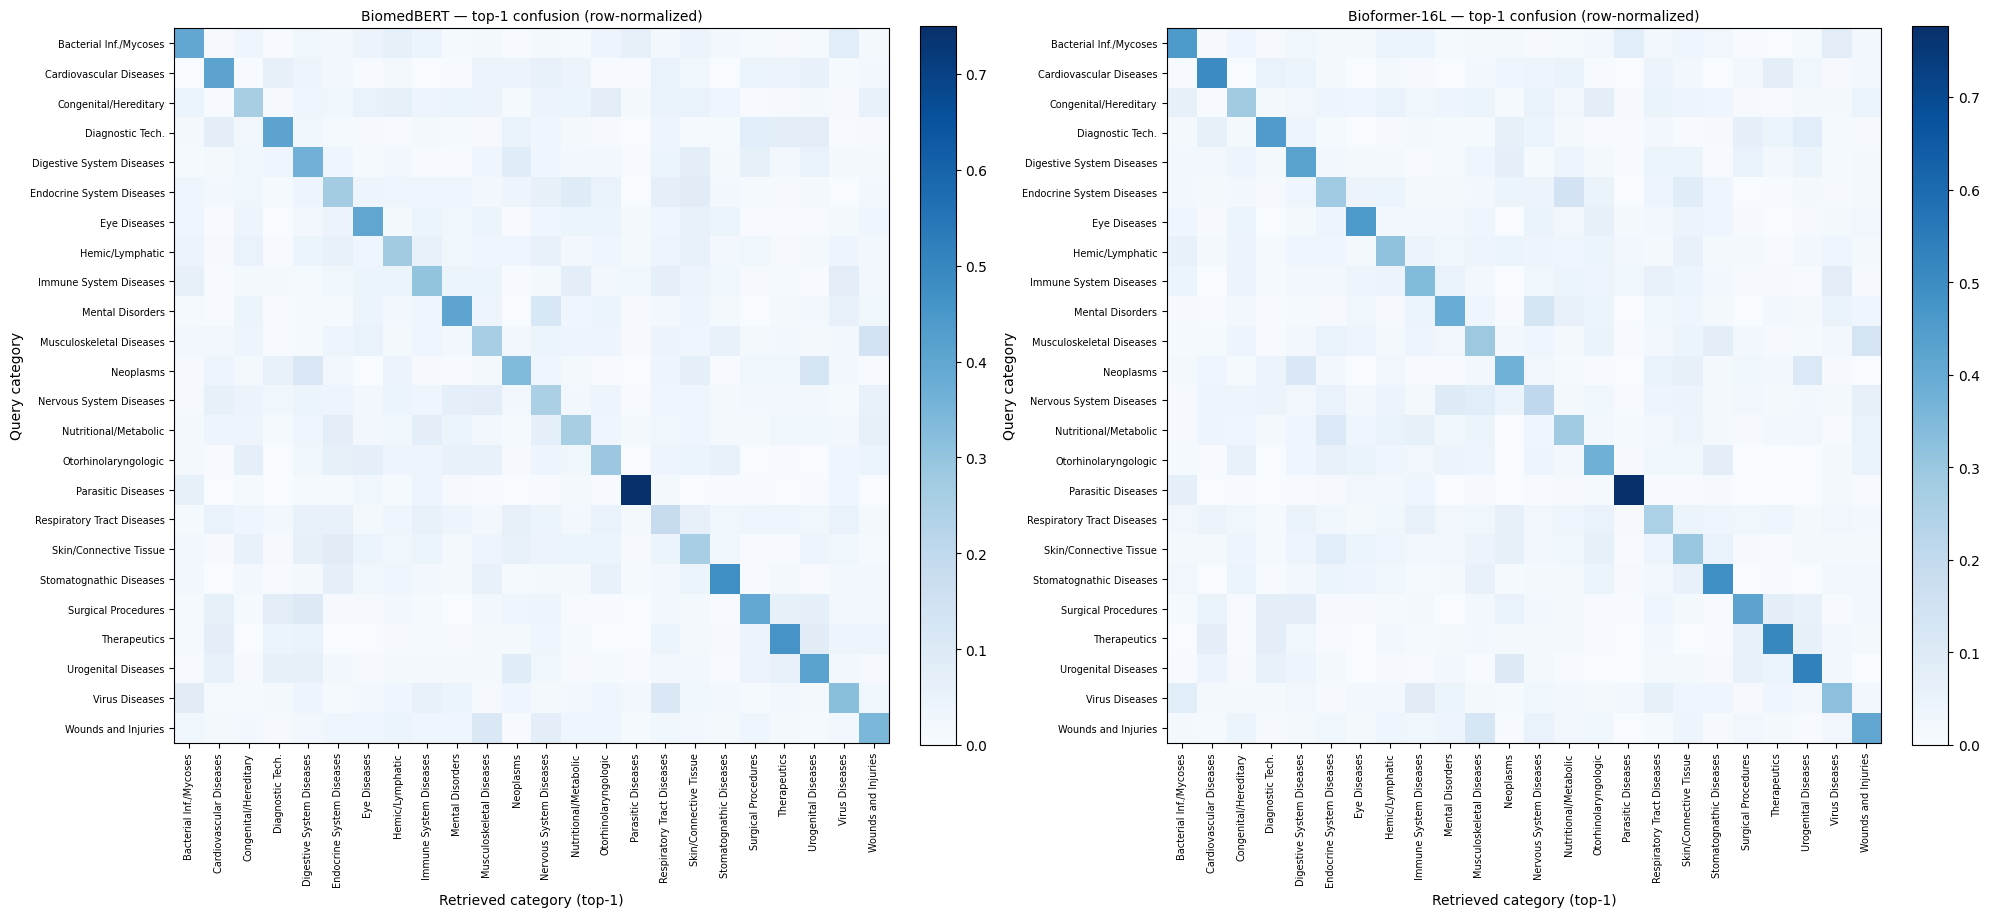


=== Top-5 cross-category confusions (BiomedBERT) ===

BiomedBERT:
  Musculoskeletal Diseases            → Wounds and Injuries                  0.137
  Neoplasms                           → Urogenital Diseases                  0.127
  Mental Disorders                    → Nervous System Diseases              0.117
  Wounds and Injuries                 → Musculoskeletal Diseases             0.107
  Virus Diseases                      → Respiratory Tract Diseases           0.107

Bioformer-16L:
  Endocrine System Diseases           → Nutritional and Metabolic Diseases   0.140
  Musculoskeletal Diseases            → Wounds and Injuries                  0.137
  Mental Disorders                    → Nervous System Diseases              0.133
  Wounds and Injuries                 → Musculoskeletal Diseases             0.123
  Neoplasms                           → Digestive System Diseases            0.113


In [43]:
def build_confusion_matrix(embeddings: np.ndarray, labels: list[str]) -> tuple[np.ndarray, list[str]]:
    """
    For each document, find top-1 neighbor (self excluded).
    Returns row-normalized confusion matrix and sorted category list.
    """
    labels_arr = np.array(labels)
    unique_cats = sorted(set(labels))
    cat_to_idx = {c: i for i, c in enumerate(unique_cats)}
    n_cats = len(unique_cats)

    sim = embeddings @ embeddings.T
    np.fill_diagonal(sim, -1.0)
    top1_idx = np.argmax(sim, axis=1)

    conf = np.zeros((n_cats, n_cats), dtype=int)
    for i, j in enumerate(top1_idx):
        conf[cat_to_idx[labels_arr[i]], cat_to_idx[labels_arr[j]]] += 1

    # Row-normalize: each entry = P(retrieved cat | query cat)
    conf_norm = conf / conf.sum(axis=1, keepdims=True)
    return conf_norm, unique_cats


conf_biomed, cats_sorted = build_confusion_matrix(embeddings_biomed, labels)
conf_bioformer, _ = build_confusion_matrix(embeddings_bioformer, labels)

# Abbreviate long category names for axis labels
short_labels = [
    c.replace("Congenital, Hereditary, and Neonatal Diseases and Abnormalities", "Congenital/Hereditary")
     .replace("Bacterial Infections and Mycoses", "Bacterial Inf./Mycoses")
     .replace("Nutritional and Metabolic Diseases", "Nutritional/Metabolic")
     .replace("Skin and Connective Tissue Diseases", "Skin/Connective Tissue")
     .replace("Otorhinolaryngologic Diseases", "Otorhinolaryngologic")
     .replace("Diagnostic Techniques and Procedures", "Diagnostic Tech.")
     .replace("Surgical Procedures, Operative", "Surgical Procedures")
     .replace("Hemic and Lymphatic Diseases", "Hemic/Lymphatic")
    for c in cats_sorted
]

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, conf, title in [
    (axes[0], conf_biomed,    "BiomedBERT — top-1 confusion (row-normalized)"),
    (axes[1], conf_bioformer, "Bioformer-16L — top-1 confusion (row-normalized)"),
]:
    im = ax.imshow(conf, cmap="Blues", vmin=0, vmax=conf.max())
    ax.set_xticks(range(len(cats_sorted)))
    ax.set_yticks(range(len(cats_sorted)))
    ax.set_xticklabels(short_labels, rotation=90, fontsize=7)
    ax.set_yticklabels(short_labels, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Retrieved category (top-1)")
    ax.set_ylabel("Query category")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Print the top-5 most frequent cross-category confusions for each model
print("\n=== Top-5 cross-category confusions (BiomedBERT) ===")
n_cats = len(cats_sorted)
for model_name, conf in [("BiomedBERT", conf_biomed), ("Bioformer-16L", conf_bioformer)]:
    off_diag = [(conf[i, j], cats_sorted[i], cats_sorted[j])
                for i in range(n_cats) for j in range(n_cats) if i != j]
    off_diag.sort(reverse=True)
    print(f"\n{model_name}:")
    for val, q_cat, r_cat in off_diag[:5]:
        print(f"  {q_cat[:35]:<35} → {r_cat[:35]:<35}  {val:.3f}")